# 3_angry_mob
ensemble testing a set of pitchfork networks
ToDo:
- Plots of different solar tracks at low alpha plotted over true track
- Plots of distributions of output predictions for different points
- Plots of standard deviation of uncertainty distributions as a function of N

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
import astropy.constants

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-02-09 16:51:54.647222: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-09 16:51:54.647249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-09 16:51:54.648100: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-09 16:51:54.653273: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-09 16:51:55.209722: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-02-09 16:51:55.758674: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18447 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [2]:
#### path definition
path = Path(os.getcwd())
path = path.relative_to(*path.parts[:4])

#### load in grid
#df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/' + str(path) + '/data/df_all_log.h5', key='df')
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/df_all_log.h5', key='df')

#### normalise/standardise
for column in df_full.columns:
    df_full[column+"_std"] = (df_full[column]-df_full[column].mean())/df_full[column].std()

df_full.describe()

#### define inputs
inputs = ['initial_mass_std', 'initial_Zinit_std', 'initial_Yinit_std', 'initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'star_feh_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.995, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  2424255
Testing set:  12243
Validation set:  12183


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
count,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,...,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06
mean,1.021885e+00,1.440698e-02,2.814693e-01,2.117984e+00,5.000177e+00,1.312728e+00,2.116482e+00,5.870890e+03,-1.127145e-01,5.459277e+02,...,5.100371e-15,3.629539e-15,2.700240e-15,1.435547e-15,-4.423639e-15,8.003407e-15,-8.417543e-15,1.289578e-15,-3.185318e-15,3.670395e-15
std,1.175610e-01,9.677123e-03,2.805593e-02,2.879175e-01,3.405371e+00,4.813547e-01,1.572419e+00,5.674285e+02,3.499532e-01,2.021373e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,8.000000e-01,3.869061e-03,2.400000e-01,1.700000e+00,2.966411e-02,6.990236e-01,1.321735e-01,4.099787e+03,-1.077903e+00,1.545097e+02,...,-2.605045e+00,-2.599363e+00,-2.594960e+00,-2.591708e+00,-2.589646e+00,-2.588901e+00,-2.589287e+00,-2.590747e+00,-2.593002e+00,-2.595848e+00
25%,9.200000e-01,6.471429e-03,2.600000e-01,1.900000e+00,2.309880e+00,9.719693e-01,9.371542e-01,5.495672e+03,-4.000000e-01,3.986516e+02,...,-5.612334e-01,-5.643108e-01,-5.676179e-01,-5.705508e-01,-5.723483e-01,-5.730070e-01,-5.725672e-01,-5.713737e-01,-5.700038e-01,-5.685747e-01
50%,1.040000e+00,1.077191e-02,2.800000e-01,2.100000e+00,4.275231e+00,1.160016e+00,1.698469e+00,5.863863e+03,-1.000000e-01,5.591040e+02,...,2.414913e-01,2.417789e-01,2.415099e-01,2.405877e-01,2.389688e-01,2.369176e-01,2.348740e-01,2.333131e-01,2.326247e-01,2.327753e-01
75%,1.120000e+00,2.007835e-02,3.000000e-01,2.300000e+00,7.159688e+00,1.498369e+00,2.883064e+00,6.223793e+03,1.837200e-01,6.947397e+02,...,7.562359e-01,7.569644e-01,7.578097e-01,7.587334e-01,7.595544e-01,7.599729e-01,7.598420e-01,7.591873e-01,7.580180e-01,7.566985e-01
max,1.200000e+00,3.897971e-02,3.200000e-01,2.500000e+00,1.399997e+01,2.873431e+00,1.163902e+01,7.998610e+03,5.094573e-01,1.021990e+03,...,1.616724e+00,1.617024e+00,1.618137e+00,1.620054e+00,1.622624e+00,1.625764e+00,1.629202e+00,1.632519e+00,1.633559e+00,1.635647e+00


In [4]:
"""
pca
"""
#### define pca global vars
n_components = 4
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 4 is 0.999999896009264


In [5]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()

unlog_weights = [0.1] / df_full['star_feh'].std()

weights = log_weights.values[[0,1]].tolist() + unlog_weights.tolist() + log_weights.values[2:].tolist()

print(weights)

[0.02324560601067967, 0.012220076304794422, 0.2857524907848119, 0.00012220154533326764, 0.00011530706805035573, 0.000109209187475727, 0.00010373957827574545, 9.877493746324607e-05, 9.424043658607474e-05, 9.008674371702482e-05, 8.626668769588676e-05, 8.273438289926203e-05, 7.944721575439512e-05, 7.636537366843286e-05]


## 2) solar track predictions
checking diag_dash scripts for this code, extract solar type track and plot over pitchfork predictions at low alpha

In [6]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

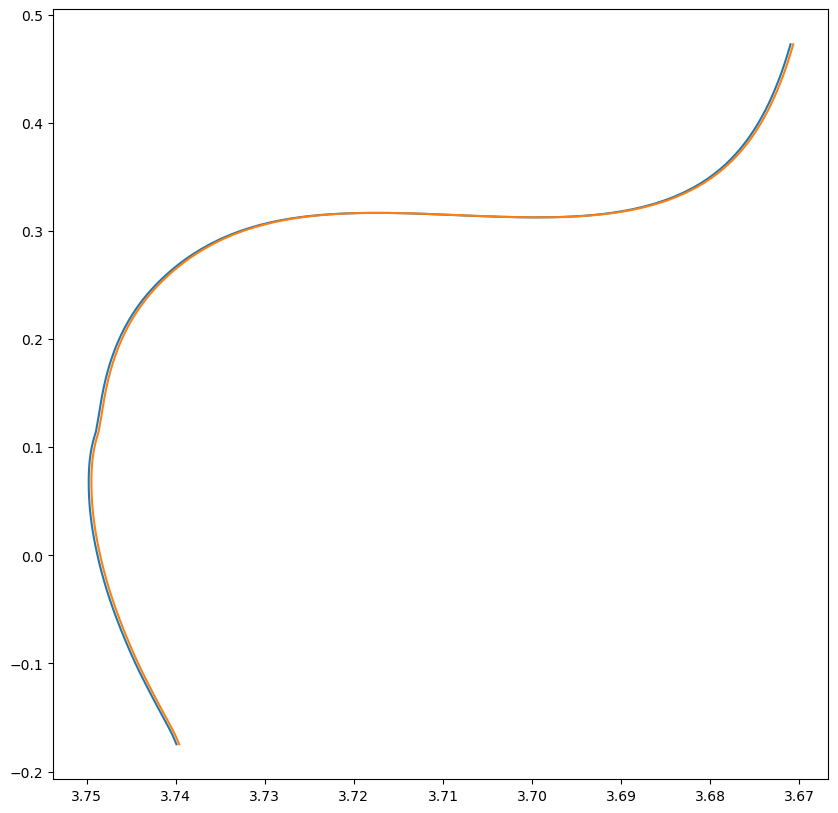

In [192]:
# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))

fig, ax = plt.subplots(figsize=(10,10), dpi=100)
plt.plot(df_mass_zinit["log_effective_T"], df_mass_zinit["log_luminosity"])

df_mass_zinit["calculated_effective_T"] = calc_Teff(df_mass_zinit["luminosity"], df_mass_zinit["radius"])

plt.plot(np.log10(df_mass_zinit["calculated_effective_T"]), np.log10(df_mass_zinit["luminosity"]))
plt.gca().invert_xaxis()

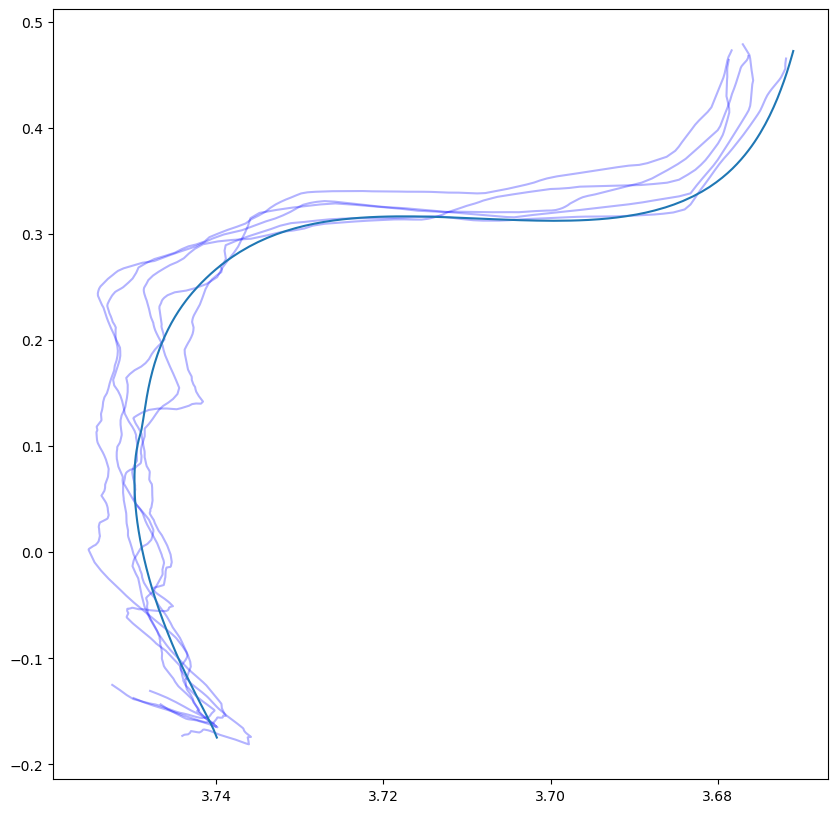

In [8]:
pca_comps = pca.components_
pca_mean = pca.mean_

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}


fig, ax = plt.subplots(figsize=(10,10), dpi=100)
for i in range(5):
    pitchfork_name = "pitchfork_"+str(i)
    
    pcann_model = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/" + str(path) + "/models/angry_mob_1/" + pitchfork_name + ".h5", custom_objects=custom_objects)
    
    preds = pcann_model(np.array(df_mass_zinit[inputs]))
    
    classical_preds = pd.DataFrame(np.array(preds[0]), columns=[classical_outputs])

    for classical_output in ['radius', 'luminosity']:
        classical_preds["log_"+classical_output] = (classical_preds["log_"+classical_output+"_std"]*df_full["log_"+classical_output].std())+df_full["log_"+classical_output].mean()
        classical_preds[classical_output] = 10**classical_preds["log_" + classical_output]
    
    plt.plot(np.log10(calc_Teff(classical_preds["luminosity"],classical_preds["radius"])), np.log10(classical_preds["luminosity"]), alpha=0.3, c='blue')


plt.plot(df_mass_zinit["log_effective_T"], df_mass_zinit["log_luminosity"])


plt.gca().invert_xaxis()

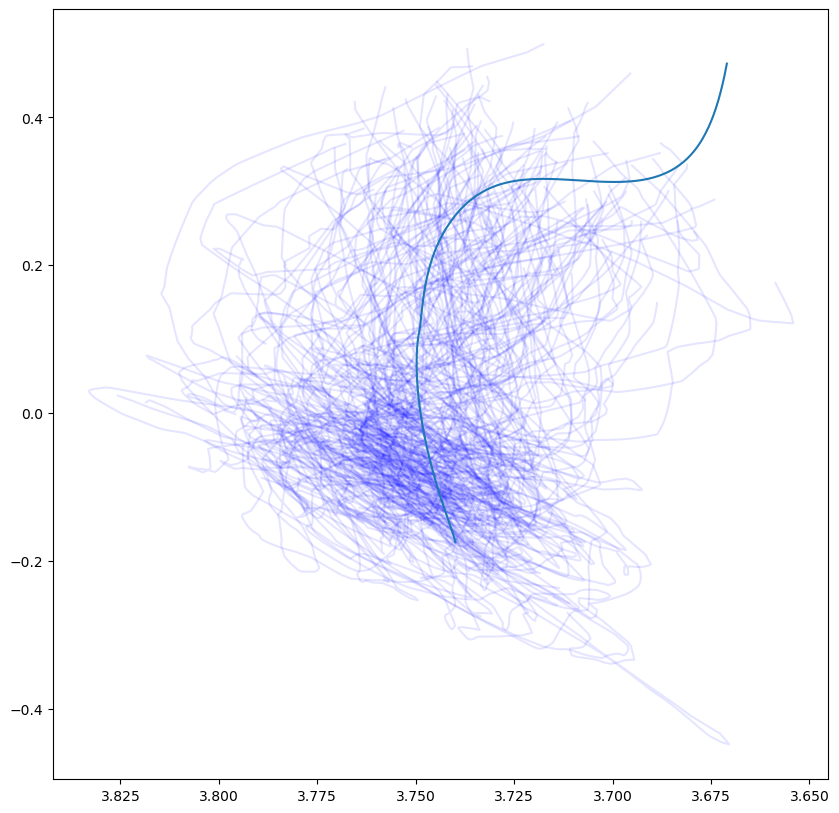

In [10]:
pca_comps = pca.components_
pca_mean = pca.mean_

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}


fig, ax = plt.subplots(figsize=(10,10), dpi=100)
for i in range(140):
    pitchfork_name = "pitchfork_"+str(i)
    
    pcann_model = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/" + str(path) + "/models/angry_mob/" + pitchfork_name + ".h5", custom_objects=custom_objects)
    
    preds = pcann_model(np.array(df_mass_zinit[inputs]))
    
    classical_preds = pd.DataFrame(np.array(preds[0]), columns=[classical_outputs])

    for classical_output in ['radius', 'luminosity']:
        classical_preds["log_"+classical_output] = (classical_preds["log_"+classical_output+"_std"]*df_full["log_"+classical_output].std())+df_full["log_"+classical_output].mean()
        classical_preds[classical_output] = 10**classical_preds["log_" + classical_output]
    
    plt.plot(np.log10(calc_Teff(classical_preds["luminosity"],classical_preds["radius"])), np.log10(classical_preds["luminosity"]), alpha=0.1, c='blue')


plt.plot(df_mass_zinit["log_effective_T"], df_mass_zinit["log_luminosity"])


plt.gca().invert_xaxis()

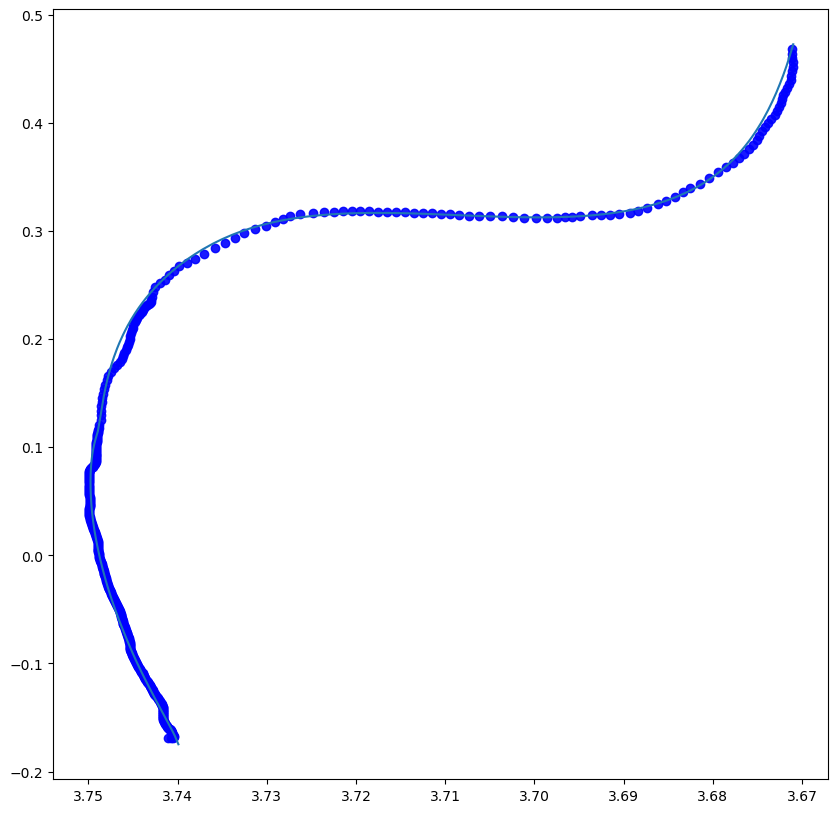

In [199]:
pca_comps = pca.components_
pca_mean = pca.mean_

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}


fig, ax = plt.subplots(figsize=(10,10), dpi=100)
for i in range(1):
    pitchfork_name = "stem_4_64_ctine_6_64_atine_6_256_WMSE"
    
    pcann_model = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/" + str(path) + "/models/" + pitchfork_name + ".h5", custom_objects=custom_objects)
    
    preds = pcann_model(np.array(df_mass_zinit[inputs]))
    
    classical_preds = pd.DataFrame(np.array(preds[0]), columns=[classical_outputs])

    for classical_output in ['radius', 'luminosity']:
        classical_preds["log_"+classical_output] = (classical_preds["log_"+classical_output+"_std"]*df_full["log_"+classical_output].std())+df_full["log_"+classical_output].mean()
        classical_preds[classical_output] = 10**classical_preds["log_" + classical_output]
    
    plt.scatter(np.log10(calc_Teff(classical_preds["luminosity"],classical_preds["radius"])), np.log10(classical_preds["luminosity"]), alpha=0.9, c='blue')


plt.plot(df_mass_zinit["log_effective_T"], df_mass_zinit["log_luminosity"])


plt.gca().invert_xaxis()